In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [34]:
base_path = "/Users/kdt_0900_cjs/ml/resource/dataset"
file_name = "fish.csv"
file_path = os.path.join(base_path, file_name)

In [35]:
df = pd.read_csv(file_path)
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [36]:
df["Species"].unique()
# 7개 종류의 물고기 종류가 있다

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

### fish 종류
    Bream: 도미류
    Roach: 잉어과 담수어
    Whitefish: 송어
    Parkki: 청돔
    Perch: 농어
    Pike: 강꼬치고기
    Smelt: 빙어

### fish 컬럼 설명
| 컬럼명 (Column) | 설명 (Description) | 단위 (Unit) |
| :--- | :--- | :--- |
| **Species** | 물고기의 종류 (예: Bream, Smelt 등) | 분류 (텍스트) |
| **Weight** | 물고기의 무게 | 그램 (g) |
| **Length** | 물고기의 길이 | 센티미터 (cm) |
| **Diagonal** | 물고기의 대각선 길이 | 센티미터 (cm) |
| **Height** | 물고기의 최대 높이 | 센티미터 (cm) |
| **Width** | 물고기의 최대 너비 | 센티미터 (cm) |

In [37]:
df["Species"].value_counts()
# 불균형한 데이터. 개체별 데이터 개수가 다름.

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [39]:
df.describe()
# 무게가 0이 나가는 게 있다고 함. 이상치일 가능성 큼. 1650키로가 맥스 몸무게라는 것도 이상치로 의심.

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


## 분류 문제 지도학습 목표
- 생선의 길이와 무게 만으로 생선의 종류를 분류
- 도미, 빙어(Bream, smelt)

[25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
[242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


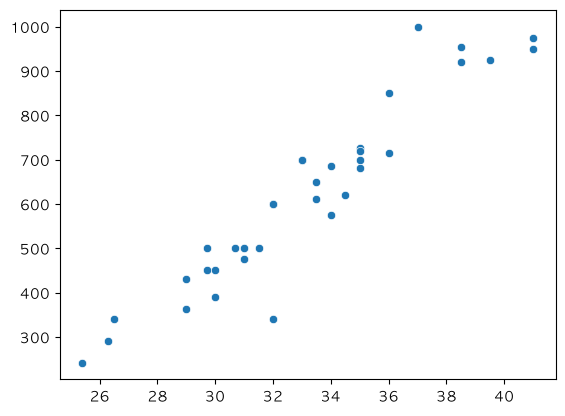

In [40]:
# Bream: 도미(총 35개 데이터)
bream_length = list(df[df["Species"]=="Bream"]["Length"])


bream_weight = list(df[df["Species"]=="Bream"]["Weight"])


print(bream_length)
print(bream_weight)

sns.scatterplot(x=bream_length, y=bream_weight)
plt.show()

[25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
[242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


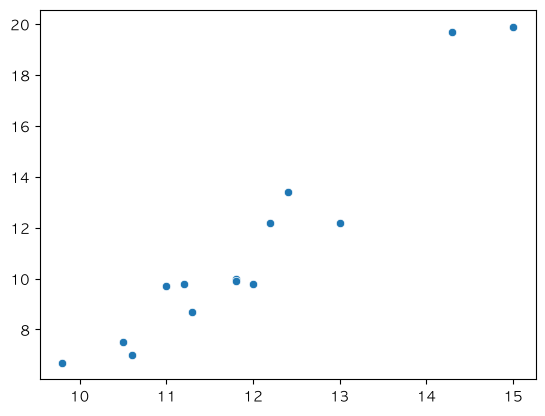

In [41]:
# Smelt: 빙어(총 14개 데이터)
smelt_length = list(df[df["Species"]=="Smelt"]["Length"])


smelt_weight = list(df[df["Species"]=="Smelt"]["Weight"])


print(bream_length)
print(bream_weight)

sns.scatterplot(x=smelt_length, y=smelt_weight)
plt.show()

<Axes: >

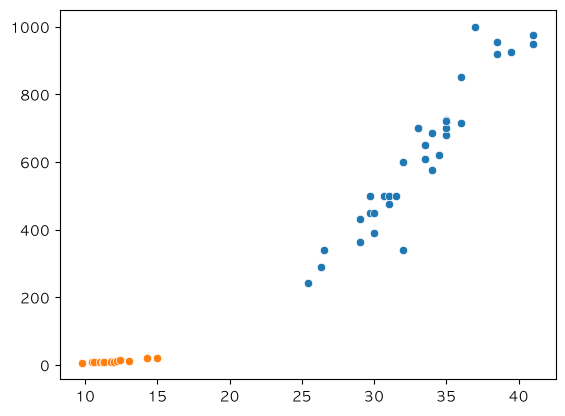

In [42]:
sns.scatterplot(x=bream_length, y=bream_weight)
sns.scatterplot(x=smelt_length, y=smelt_weight)

In [43]:
#"Bream", "Smelt" 두 개 값만 들어가게 하기
fish_df = df[df["Species"].isin(["Bream", "Smelt"])]
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


분류형 데이터를 수치형 데이터로 바꿔야 함. -> 인코딩 작업. 
분류형 인코딩으로 해야함.

## 분류형 데이터 인코딩

In [44]:
fish_df["Species"].map(lambda specie : {"Bream":0, "Smelt":1}[specie])

#받자마자 바로 쓸 때에는 참조형으로 만들기 가능
fish_df["Species"]=fish_df["Species"].map({"Bream":0, "Smelt":1})

In [45]:
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340


## 1단계, 데이터 준비(탐색)

In [46]:
fish_df.info()
#데이터의 컬럼들이나 값들을 눈으로 확인하기

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     int64  
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.7 KB


In [47]:
fish_df.describe()
# 무게의 위아래 편차가 크다. 2분위수와 1분위수도 다름. 이상치는 아님. 원래 그런 생선들이니까.
#이상치도 , 결측치도 없으면 일단 시각화 해보기


,Species,Weight,Length,Diagonal,Height,Width
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.285714,444.500000,27.055102,31.120408,11.476400,4.259751
std,0.456435,328.143233,10.242804,12.097296,6.150976,1.967686
min,0.000000,6.700000,9.800000,10.800000,1.728400,1.047600
25%,0.000000,19.700000,14.300000,15.200000,2.872800,1.879200
50%,0.000000,500.000000,31.000000,36.200000,14.179500,5.072800
75%,1.000000,700.000000,34.500000,39.700000,15.633000,5.589000
max,1.000000,1000.000000,41.000000,46.500000,18.957000,6.749700


In [48]:
fish_df=fish_df.drop(["Diagonal", "Height", "Width"], axis=1)
fish_df.head()

,Species,Weight,Length
0,0,242.0,25.4
1,0,290.0,26.3
2,0,340.0,26.5
3,0,363.0,29.0
4,0,430.0,29.0


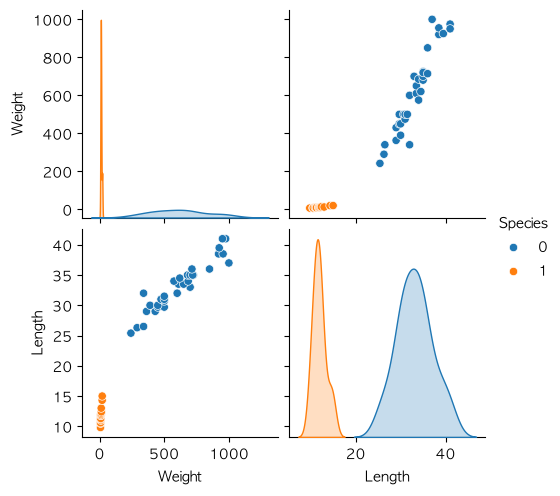

In [49]:
sns.pairplot(fish_df, hue="Species")
plt.show()

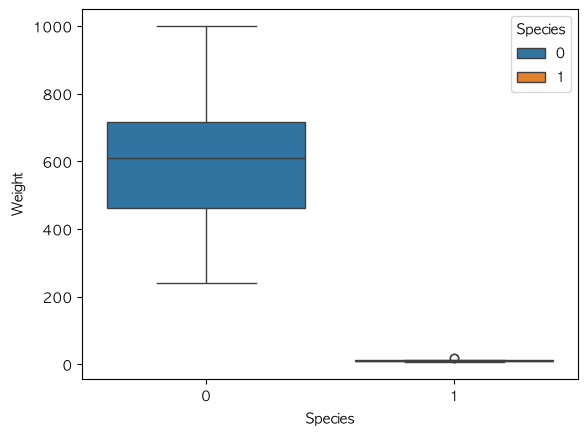

In [50]:
sns.boxplot(fish_df,x= "Species", y="Weight", hue="Species")
plt.show()

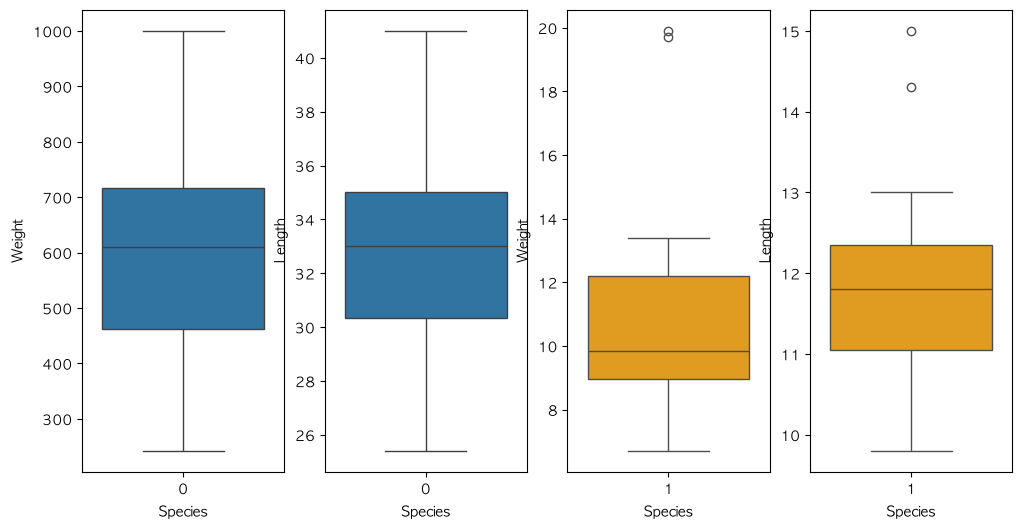

In [51]:
pig, axes = plt.subplots(1, 4, figsize=(12, 6))
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Weight", ax=axes[0])
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Length", ax=axes[1])
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Weight", ax=axes[2], color="orange")
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Length", ax=axes[3], color="orange")
plt.show()

## 2단계, 데이터 분할

In [52]:
# 독립 변수들 =X(Weight,Weight), 종속 변수(Species)
fish_df.head()

X=fish_df.drop("Species", axis=1)
X.head()

,Weight,Length
0,242.0,25.4
1,290.0,26.3
2,340.0,26.5
3,363.0,29.0
4,430.0,29.0


In [53]:
y= fish_df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [54]:
# 과소적합, 과대적합을 막기 위해 분할을 하는 거
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape,y_train.shape, y_test.shape )

(39, 2) (10, 2) (39,) (10,)


## 3단계, 모델 준비

# KNN (k-최근접 이웃, K-neighbors)알고리즘
- 어떤 데이터에 대한 답을 구할 때 주변의 다른 데이터를 보고 다수를 차지하는 데이터를 정답으로 결정하는 방식의 알고리즘

## KNN 장점
- 데이터만 있으면 알고리즘을 사용할 수 있다.

## KNN 단점
- 데이터가 많으면 사용하기 힘들며, 많은 메모리를 사용한다.

In [55]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

## 4단계, 모델 학습

In [56]:
# 표준화가 안 된 쓰레기 데이터
kn.fit(X_train, y_train)
#fit=학습

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 5단계, 모델 예측

In [57]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_test))

#예측 잘 함 굿

[0 1 0 0 0 0 0 1 1 0]
[0, 1, 0, 0, 0, 0, 0, 1, 1, 0]


## 6단계, 모델 평가

In [58]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [59]:
# print(f"accuracy_score: {kn.score(X_train, y_train)}")
print(f"accuracy_score: {accuracy_score(y_test, y_pred)}")


accuracy_score: 1.0


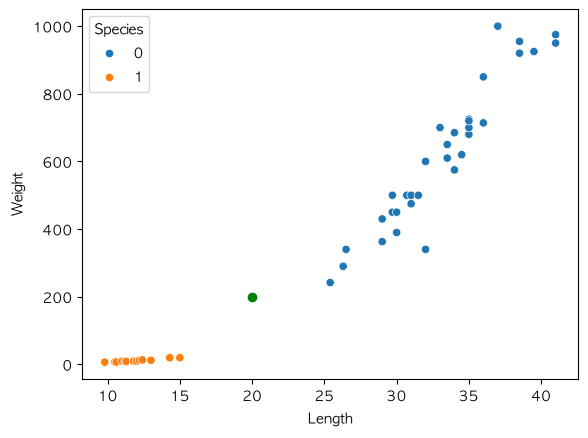

In [64]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20,200, color = "green")
plt.show()

In [65]:
columns = X_train.columns
new_data=pd.DataFrame([[20, 200]], columns=columns)
new_data

,Weight,Length
0,20,200


In [68]:
kn.kneighbors(new_data)

(array([[185.00002703, 185.70024233, 187.1626031 , 187.71606218,
         188.47082002]]),
 array([[32, 35, 10,  6,  4]]))

In [73]:
neighbors = X_train.iloc[indexs[0]]


In [67]:
distance, indexs = kn.kneighbors(new_data)

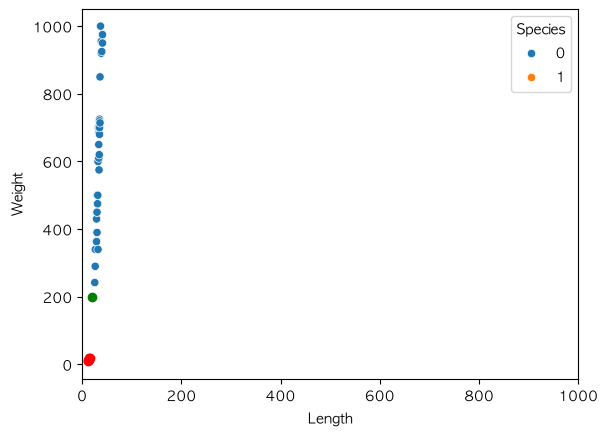

In [75]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20,200, color = "green")
plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
plt.xlim(0, 1000)
plt.show()

In [94]:
# StandardScaler 표준화
from sklearn.preprocessing import StandardScaler

# (데이터 값 - 평균) /표준편차
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
# (데이터 값 - 평균) / 표준편차

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
print(mean)
print(std)

Weight    453.935897
Length     27.158974
dtype: float64
Weight    327.314297
Length     10.150122
dtype: float64


In [104]:
X_train_scaled_df =(X_train - mean) / std
X_train_scaled_df["Species"] = y_train
X_train_scaled_df.head()

,Weight,Length,Species
32,1.439180,1.215850,0
17,0.751767,0.575464,0
145,-1.366381,-1.710223,1
21,0.705940,0.673985,0
152,-1.356604,-1.513181,1


In [105]:
new_data_scaled = (new_data - mean) / std
new_data_scaled

,Weight,Length
0,-1.325747,17.028467


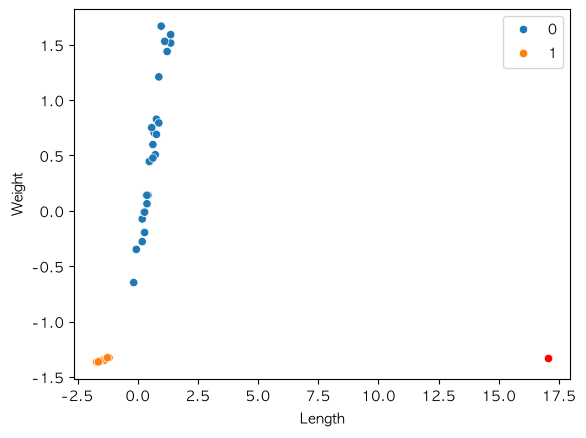

In [109]:
sns.scatterplot(X_train_scaled_df, x="Length", y="Weight", hue="Species")
sns.scatterplot(new_data_scaled, x="Length", y="Weight", color="red")
# plt.scatter(20,200, color = "green")

# plt.xlim(0, 1000)
plt.show()

## 사이킷런 모델 학습 사이클

In [110]:
kn = KNeighborsClassifier()

In [111]:
# 모델 학습
kn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [112]:
#모델 예측
y_pred = kn.predict(X_test_scaled)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0])

In [113]:
# 모델 평가
accuracy_score(y_pred, y_test)

1.0

In [116]:
#혼동 행렬 
cm = confusion_matrix(y_test, y_pred)
cm

array([[7, 0],
       [0, 3]])

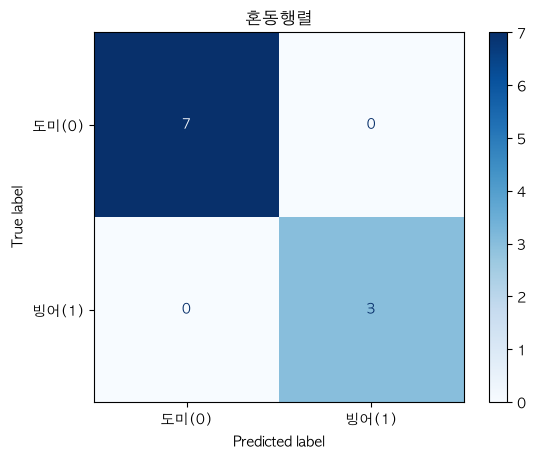

In [123]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ["도미(0)", "빙어(1)"])
display.plot(cmap = "Blues")
plt.title("혼동행렬")
plt.show()